#IDENTITAS : GALIH SETYO P.

**Problem:**

Dalam aktivitas olahraga, tidak semua orang memiliki akses terhadap smartwatch atau perangkat fitness tracker yang dapat menghitung kalori secara otomatis. Oleh karena itu, diperlukan suatu model prediksi yang mampu mengestimasi jumlah kalori yang terbakar berdasarkan karakteristik seseorang dan data aktivitas olahraga yang mudah diperoleh.

**Tujuan** mini project ini dibuat untuk:
1. memprediksi jumlah kalori yang terbakar selama berolahraga.
2. mengetahui faktor apa yg berkontribusi paling besar terhadap proses pembakaran energi di dalam tubuh manusia.
3. membandingkan performa beberapa algoritma Machine Learning dalam memprediksi kalori yang terbakar.
---



#Load Dataset
dataset ini terdiri dari 2 file:
1. calories.csv terdiri dari 2 kolom dan 15000 baris
2. exercise.csv terdiri dari 8 kolom dan 15000 baris

dataset berisi data karakteristik seseorang dan aktivitas olahraga yang dilakukan meliputi user ID, usia, jenis kelamin, tinggi badan, berat badan, durasi latihan, detak jantung, suhu tubuh, dan kalori

Sumber dataset kaggle.com
https://www.kaggle.com/datasets/fmendes/fmendesdat263xdemos/data

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file1_path = "calories.csv"

df_calories= kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "fmendes/fmendesdat263xdemos",
  file1_path
)


/tmp/ipykernel_1329/3630973387.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_calories= kagglehub.load_dataset(


100%|██████████| 225k/225k [00:00<00:00, 19.5MB/s]


In [2]:
file2_path = "exercise.csv"

df_exercise = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "fmendes/fmendesdat263xdemos",
  file2_path
)

/tmp/ipykernel_1329/4249979542.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_exercise = kagglehub.load_dataset(


Using Colab cache for faster access to the 'fmendesdat263xdemos' dataset.


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV

##Dataset 1 (calories.csv)

In [4]:
df_calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [5]:
df_calories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User_ID   15000 non-null  int64  
 1   Calories  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 234.5 KB


In [6]:
df_calories.isnull().sum()

,0
User_ID,0
Calories,0


In [7]:
df_calories.duplicated().sum()

np.int64(0)

In [8]:
df_calories.describe()

,User_ID,Calories
count,1.500000e+04,15000.000000
mean,1.497736e+07,89.539533
std,2.872851e+06,62.456978
min,1.000116e+07,1.000000
25%,1.247419e+07,35.000000
50%,1.499728e+07,79.000000
75%,1.744928e+07,138.000000
max,1.999965e+07,314.000000


##Dataset 2 (exercise.csv)

In [9]:
df_exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [10]:
df_exercise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 937.6+ KB


In [11]:
df_exercise.isnull().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0


In [12]:
df_exercise.duplicated().sum()

np.int64(0)

In [13]:
df_exercise.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000


#Menggabungkan dataset

In [14]:
df = pd.concat([df_exercise, df_calories['Calories']], axis=1)
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


#---MINI PROJECT 1---

##EDA

###Distribusi Data col_numerik

In [15]:
col_numerik = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']

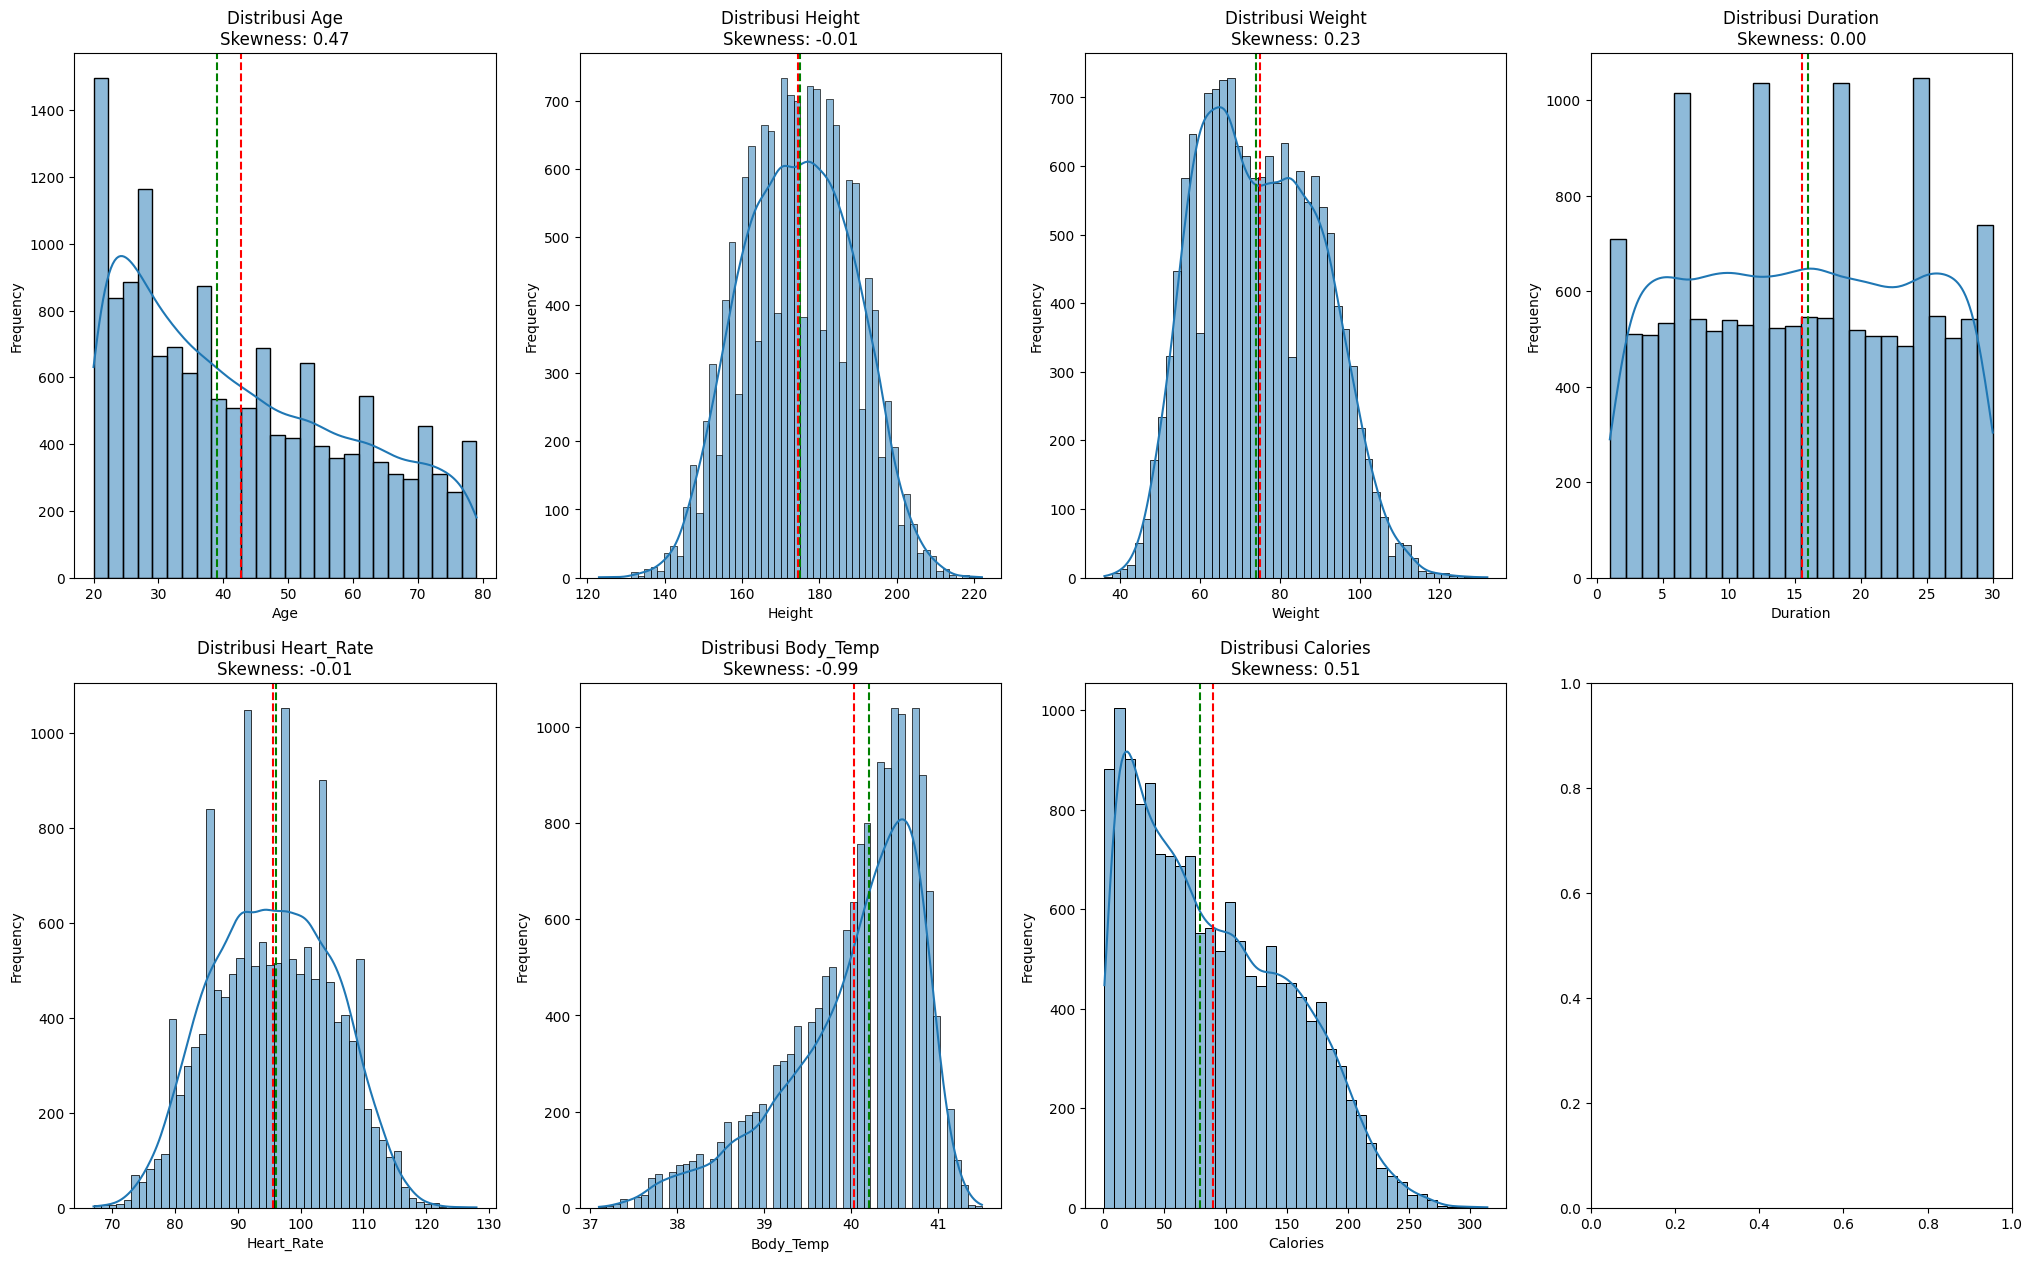

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(25, 15))
axes = axes.flatten()

for i, col in enumerate(col_numerik):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].axvline(df[col].mean(), color='r', linestyle='--')
    axes[i].axvline(df[col].median(), color='g', linestyle='--')
    axes[i].set_title(f'Distribusi {col}\nSkewness: {df[col].skew():.2f}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.show()

sebagian fitur dapat dikatakan normal dengan nilai skewness antara -0,5 hingga 0,5.
untuk fitur Body_Temp memiliki skewness negatif yang menunjukkan distribusi lebih banyak berada pada nilai tinggi. Sedangkan, Calories memiliki skewness positif yang menunjukkan sebagian kecil observasi memiliki nilai kalori yang sangat tinggi.

###Distribusi Gender

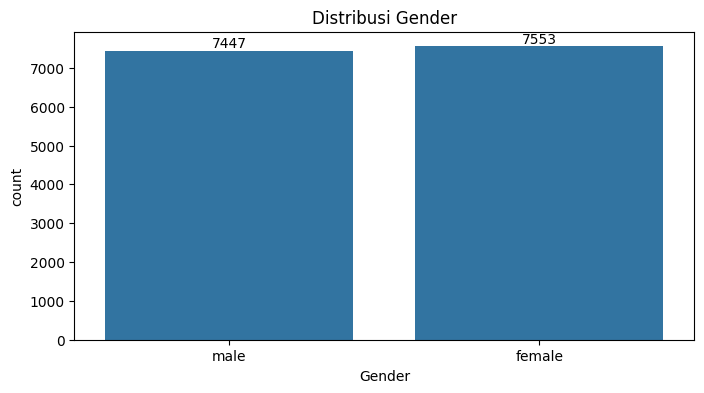

In [17]:
fig, ax = plt.subplots(1,1, figsize=(8 , 4))

ax1 = sns.countplot(data=df, x='Gender', ax=ax)
ax.set_title("Distribusi Gender")
ax1.bar_label(ax1.containers[0])
plt.show()

###Durasi Olahraga vs Pembakaran Kalori

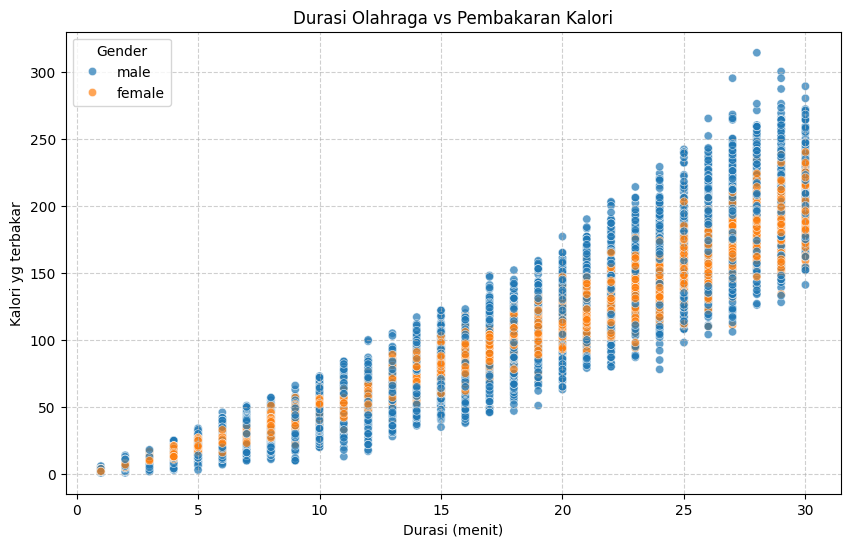

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Duration', y='Calories', data=df, hue='Gender', alpha=0.7)
plt.title('Durasi Olahraga vs Pembakaran Kalori')
plt.xlabel('Durasi (menit)')
plt.ylabel('Kalori yg terbakar')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

###Kalori yg terbakar berdasar jenis kelamin

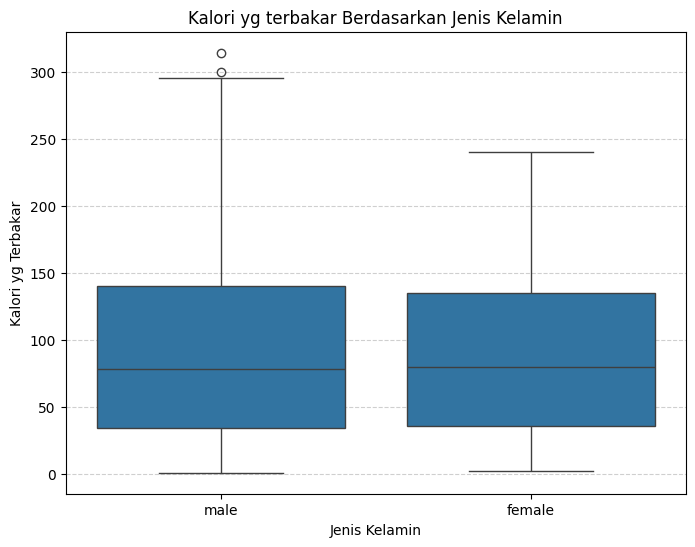

In [19]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Calories', data=df)
plt.title('Kalori yg terbakar Berdasarkan Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Kalori yg Terbakar')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

###Heart Rate berdasarkan Gender

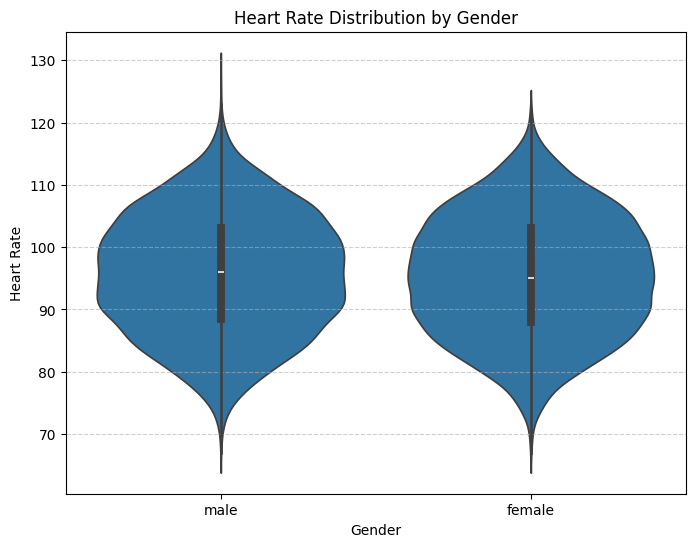

In [20]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Gender', y='Heart_Rate', data=df)
plt.title('Heart Rate Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Heart Rate')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

###Hipotesis Gender vs Calories


H0: Tidak ada perbedaan rata-rata kalori terbakar antara laki-laki dan perempuan.

H1: Terdapat perbedaan rata-rata kalori terbakar antara laki-laki dan perempuan

In [21]:
from scipy.stats import ttest_ind

male = df[df['Gender']=='male']['Calories']
female = df[df['Gender']=='female']['Calories']

t_stat, p_value = ttest_ind(male, female)

print("T-statistic :", t_stat)
print("P-value :", p_value)

T-statistic : 2.73868395056871
P-value : 0.006175846213736039


Dapat dikatakan bahwa terdapat perbedaan rata-rata jumlah kalori yang terbakar antara laki-laki dan perempuan yang signifikan secara statistik.
berdasarkan hasil Sample T-Test diperoleh nilai t-statistic sebesar 2,739 dan p-value sebesar 0,006. Karena nilai p-value lebih kecil dari 0,05, maka H₀ ditolak.

###Korelasi

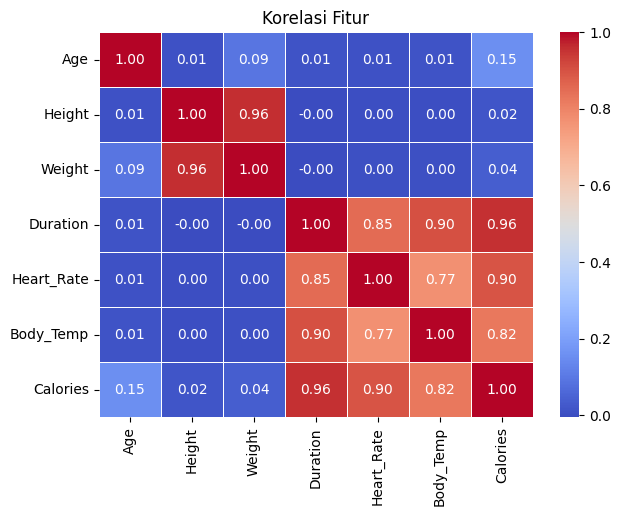

In [22]:
plt.figure(figsize=(7, 5))
corr_all = df.drop(columns=['User_ID']).corr(numeric_only=True)
sns.heatmap(corr_all, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Korelasi Fitur')
plt.show()

In [23]:
df.corr(numeric_only=True)['Calories'].sort_values(ascending=False)

,Calories
Calories,1.000000
Duration,0.955421
Heart_Rate,0.897882
Body_Temp,0.824558
Age,0.154395
Weight,0.035481
Height,0.017537
User_ID,-0.001661


Berdasarkan analisis korelasi, fitur Duration, Heart_Rate, dan Body_Temp memiliki hubungan yang kuat terhadap jumlah kalori yang terbakar.

dan terlihat bahwa adanya multikolinearitas antar fitur X yang mana akan

##Data Cleaning

###Hapus Kolom `User_ID`

In [24]:
df_cleaned = df.drop(columns=['User_ID'])

In [25]:
df_cleaned.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0


##PreProcessing Data

In [26]:
X = df_cleaned.drop(['Calories'], axis=1) #fitur
y = df_cleaned['Calories'] #target

In [27]:
X.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,male,68,190.0,94.0,29.0,105.0,40.8
1,female,20,166.0,60.0,14.0,94.0,40.3
2,male,69,179.0,79.0,5.0,88.0,38.7
3,female,34,179.0,71.0,13.0,100.0,40.5
4,female,27,154.0,58.0,10.0,81.0,39.8


In [28]:
y.head()

,Calories
0,231.0
1,66.0
2,26.0
3,71.0
4,35.0


###Cek Outlier

In [29]:
total_rows = X.shape[0] #total baris data

outlier_cols = ["Body_Temp","Weight",]  # kolom yang punya outlier berdasar grafik distribusi data (EDA)

In [30]:
X_cleaned = X.copy()
y_cleaned = y.copy()

all_outlier_indices = set()

for col in outlier_cols:
    Q1 = X_cleaned[col].quantile(0.25)
    Q3 = X_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    #ambil indeks baris data yang di luar batas
    outlier_filter = (X_cleaned[col] < lower_bound) | (
        X_cleaned[col] > upper_bound
    )
    outlier_indices = X_cleaned[outlier_filter].index

    all_outlier_indices.update(outlier_indices)

    #persentase outlier
    col_outlier_count = len(outlier_indices)
    col_outlier_persentase = (col_outlier_count / total_rows) * 100

    print(f"Kolom: {col}")
    print(f"  - Batas Bawah : {lower_bound:.2f}")
    print(f"  - Batas Atas  : {upper_bound:.2f}")
    print(
        f"  - Jumlah Outlier Terdeteksi: {col_outlier_count} baris ({col_outlier_persentase:.2f}%)"
    )

#total outlier unik
total_outliers = len(all_outlier_indices)
outlier_persentase = (total_outliers / total_rows) * 100

print(f"\nTOTAL OUTLIER")
print(
    f"Total baris outlier: {total_outliers} dari {total_rows} baris"
)
print(f"Persentase Outlier    : {outlier_persentase:.2f}%")

Kolom: Body_Temp
  - Batas Bawah : 38.10
  - Batas Atas  : 42.10
  - Jumlah Outlier Terdeteksi: 369 baris (2.46%)
Kolom: Weight
  - Batas Bawah : 27.00
  - Batas Atas  : 123.00
  - Jumlah Outlier Terdeteksi: 6 baris (0.04%)

TOTAL OUTLIER
Total baris outlier: 374 dari 15000 baris
Persentase Outlier    : 2.49%


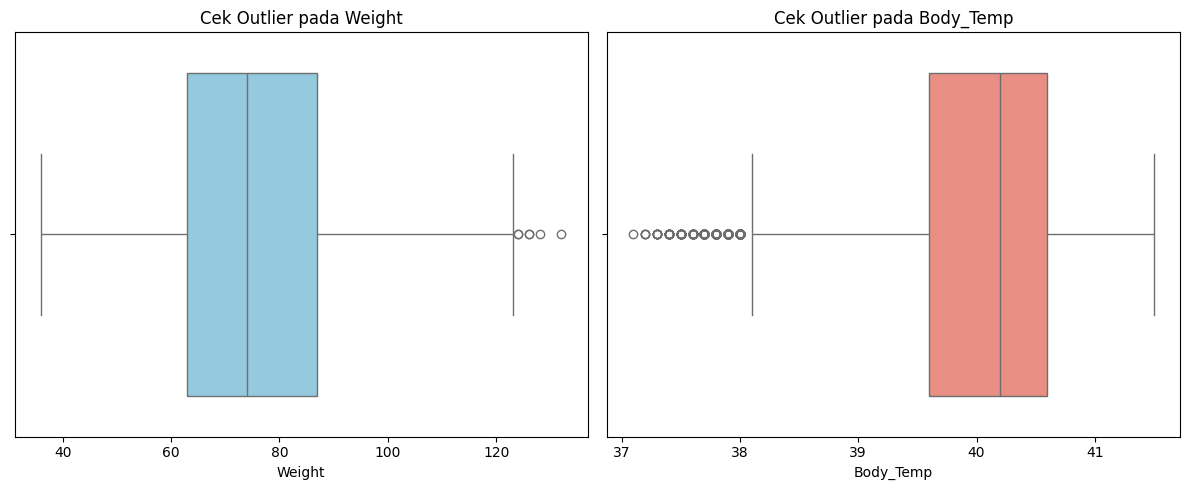

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(ax=axes[0], x=X["Weight"], color="skyblue")
axes[0].set_title("Cek Outlier pada Weight")

sns.boxplot(ax=axes[1], x=X["Body_Temp"], color="salmon")
axes[1].set_title("Cek Outlier pada Body_Temp")

plt.tight_layout()
plt.show()


###VIF, Encoding kolom `Gender`, & drop kolom `Height`, `Weight`,dan `Body_Temp`

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

In [33]:
X_numeric = X.copy()

# Encode kolom'Gender'
X_numeric['Gender'] = X_numeric['Gender'].map({'male': 1, 'female': 0})

calc_vif(X_numeric).sort_values(by='VIF', ascending=False)

,variables,VIF
2,Height,2036.722981
6,Body_Temp,1067.014525
3,Weight,463.577840
5,Heart_Rate,362.037997
4,Duration,14.053423
1,Age,8.212611
0,Gender,5.594581


In [34]:
X_numeric.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,1,68,190.0,94.0,29.0,105.0,40.8
1,0,20,166.0,60.0,14.0,94.0,40.3
2,1,69,179.0,79.0,5.0,88.0,38.7
3,0,34,179.0,71.0,13.0,100.0,40.5
4,0,27,154.0,58.0,10.0,81.0,39.8


In [35]:
X_cleaned = X_numeric.copy()

#menggabungkan Height dan Weight menjadi BMI
X_cleaned['BMI'] = X_cleaned['Weight'] / ((X_cleaned['Height'] / 100) ** 2)
X_cleaned.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI
0,1,68,190.0,94.0,29.0,105.0,40.8,26.038781
1,0,20,166.0,60.0,14.0,94.0,40.3,21.773842
2,1,69,179.0,79.0,5.0,88.0,38.7,24.655910
3,0,34,179.0,71.0,13.0,100.0,40.5,22.159109
4,0,27,154.0,58.0,10.0,81.0,39.8,24.456063


In [36]:
X_cleaned = X_numeric.copy()

# 1. Menggabungkan Height dan Weight menjadi BMI
X_cleaned['BMI'] = X_cleaned['Weight'] / ((X_cleaned['Height'] / 100) ** 2)

# 2. Membuat kategori dari BMI (Standar WHO)
bins = [0, 18.5, 24.9, 29.9, np.inf]
labels = ['Underweight', 'Normal', 'Overweight', 'Obesity']

X_cleaned['BMI_Category'] = pd.cut(X_cleaned['BMI'], bins=bins, labels=labels, right=True)

# Menampilkan hasil
X_cleaned.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI,BMI_Category
0,1,68,190.0,94.0,29.0,105.0,40.8,26.038781,Overweight
1,0,20,166.0,60.0,14.0,94.0,40.3,21.773842,Normal
2,1,69,179.0,79.0,5.0,88.0,38.7,24.655910,Normal
3,0,34,179.0,71.0,13.0,100.0,40.5,22.159109,Normal
4,0,27,154.0,58.0,10.0,81.0,39.8,24.456063,Normal


In [37]:
bmi_cat = {'Underweight': 0, 'Normal': 1, 'Overweight': 2, 'Obesity': 3}
X_cleaned['BMI_Category_Encoded'] = X_cleaned['BMI_Category'].map(bmi_cat)
X_cleaned.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,BMI,BMI_Category,BMI_Category_Encoded
0,1,68,190.0,94.0,29.0,105.0,40.8,26.038781,Overweight,2
1,0,20,166.0,60.0,14.0,94.0,40.3,21.773842,Normal,1
2,1,69,179.0,79.0,5.0,88.0,38.7,24.655910,Normal,1
3,0,34,179.0,71.0,13.0,100.0,40.5,22.159109,Normal,1
4,0,27,154.0,58.0,10.0,81.0,39.8,24.456063,Normal,1


In [38]:
#menghapus fitur dengan VIF ekstrem (Height, Weight, Body_Temp)
features_to_drop = ['Height','Weight','Body_Temp','BMI','BMI_Category','BMI_Category_Encoded']
X_cleaned = X_cleaned.drop(columns=features_to_drop)

X_cleaned.head()

,Gender,Age,Duration,Heart_Rate
0,1,68,29.0,105.0
1,0,20,14.0,94.0
2,1,69,5.0,88.0
3,0,34,13.0,100.0
4,0,27,10.0,81.0


In [39]:
#nilai VIF setelah fitur dibersihkan
print("Hasil VIF Setelah Pembersihan")
calc_vif(X_cleaned).sort_values(by='VIF', ascending=False)


Hasil VIF Setelah Pembersihan


,variables,VIF
3,Heart_Rate,15.995513
1,Age,7.178512
2,Duration,6.550938
0,Gender,1.982785


untuk mengatasi multikolinearitas berdasarkan korelasi fitur saya mengkonversikan `TB` & `BB` menjadi `BMI` sehingga nilai VIFnya berhasil turun. untuk kolom TB dan BB dihapus karena `BMI` sudah mewakili TB dan BB.
begitupun kolom `Body_Temp` dihapus karena `heart_rate` sudah mewakili Body_Temp.

`Heart_Rate` dan `BMI` tidak saya hapus karena informasi ini sangat penting untuk memprediksi kalori yg terbakar. karena, orang dengan BMI lebih besar akan membutuhkan kinerja jantung yang lebih keras (Heart Rate) untuk menggerakkan tubuh mereka.

----
di MP02 ini saya melakukan perhitungan ulang kembali untuk VIF nya sebelum dihitung VIF nya saya melakukan feature creation membuat kolom BMI berdasarkan kolom TB BB kemudian hasil BMI dilakukan pengkategorian dengan melakukan encoding kategori BMI sesuai dengan ketentuan WHO


In [40]:
X_cleaned.head()

,Gender,Age,Duration,Heart_Rate
0,1,68,29.0,105.0
1,0,20,14.0,94.0
2,1,69,5.0,88.0
3,0,34,13.0,100.0
4,0,27,10.0,81.0


###Split Data

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

print(f"Data Train  : {X_train.shape[0]} baris")
print(f"Data Test   : {X_test.shape[0]} baris")


Data Train  : 12000 baris
Data Test   : 3000 baris


In [42]:
X_train.head()

,Gender,Age,Duration,Heart_Rate
9839,1,37,7.0,81.0
9680,1,23,26.0,110.0
7093,1,33,12.0,88.0
11293,0,66,9.0,77.0
820,0,32,5.0,90.0


###Scaling

In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#menjadikan dataframe kembali
X_train_scaled_ml = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_ml = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_train_scaled_ml.head()


,Gender,Age,Duration,Heart_Rate
0,1.007193,-0.337295,-1.021889,-1.517377
1,1.007193,-1.163322,1.266663,1.522425
2,1.007193,-0.573303,-0.419638,-0.783631
3,-0.992859,1.373763,-0.780988,-1.936660
4,-0.992859,-0.632304,-1.262789,-0.573990


##Modelling

In [44]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost Regressor': XGBRegressor(n_estimators=100, random_state=42)
}

evaluation_results = []

In [45]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    #prediksi data TRAIN & TEST
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    #eval data TRAIN
    r2_train = r2_score(y_train, y_pred_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

    #eval data TEST
    r2_test = r2_score(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

    #nyimpen hasil ke dalam list
    evaluation_results.append({
        "Model": name,
        "Data": "Train",
        "R2 Score": f"{r2_train * 100:.2f}%",
        "MAE": f"{mae_train:.2f} Kkal",
        "RMSE": f"{rmse_train:.2f}",
    })
    evaluation_results.append({
        "Model": name,
        "Data": "Test",
        "R2 Score": f"{r2_test * 100:.2f}%",
        "MAE": f"{mae_test:.2f} Kkal",
        "RMSE": f"{rmse_test:.2f}",
    })

df_eval = pd.DataFrame(evaluation_results) # hasil eval
print(df_eval.to_string(index=False))

                  Model  Data R2 Score       MAE  RMSE
      Linear Regression Train   95.85% 9.53 Kkal 12.66
      Linear Regression  Test   95.86% 9.67 Kkal 12.93
Random Forest Regressor Train   99.93% 1.05 Kkal  1.60
Random Forest Regressor  Test   99.66% 2.54 Kkal  3.70
      XGBoost Regressor Train   99.82% 1.88 Kkal  2.67
      XGBoost Regressor  Test   99.66% 2.55 Kkal  3.70


###Hyperparameter


In [46]:
#Model dasar
xgb = XGBRegressor(n_estimators=100, random_state=42)

#Parameter yang akan dicoba
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

#Hyperparameter Tuning
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameter:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameter:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

Best CV Score:
0.9967682227732855


In [47]:
best_xgb = grid_search.best_estimator_

In [48]:
y_pred = best_xgb.predict(X_test_scaled)

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score : 0.9970663193629885
MAE      : 2.356935783882936
RMSE     : 3.440889901183813


##Feature Importance

In [49]:
from sklearn.inspection import permutation_importance

best_model = models['XGBoost Regressor']

hasil_importance = permutation_importance(
    best_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42
)

importance_df = pd.DataFrame({
    'Fitur': X_cleaned.columns,
    'Importance': hasil_importance.importances_mean
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Fitur,Importance
2,Duration,1.130647
3,Heart_Rate,0.195175
1,Age,0.062961
0,Gender,0.019899


Berdasarkan feature importance dari model terbaik yaitu XGBoost Regressor menunjukan bahwa
lamanya durasi seseorang melakukan olahraga maka semakin banyak energi yang digunakan sehingga banyak kalori juga yang terbakar.

`Heart_Rate` juga  menunjukkan bahwa intensitas aktivitas fisik berperan penting dalam proses pembakaran kalori.

Sementara itu, Age, Gender memiliki kontribusi yang relatif kecil terhadap prediksi.

##Kesimpulan

1. Durasi olahraga merupakan faktor paling penting dalam menentukan jumlah kalori yang terbakar.
2. Detak jantung menjadi indikator intensitas latihan yang sangat berpengaruh terhadap pembakaran kalori.
3. Durasi olahraga merupakan faktor yang paling berpengaruh dalam prediksi jumlah kalori yang terbakar, diikuti oleh Heart_Rate, Age, Gender, dan BMI. Temuan ini mengindikasikan bahwa lama dan intensitas olahraga memiliki pengaruh yang jauh lebih besar dibandingkan karakteristik fisik seseorang.
4. Model Random Forest mampu memberikan performa prediksi yang sangat baik & error yang rendah.
----
Saran / Rekomendasi:

Untuk meningkatkan kemampuan prediksi dapat menambahkan variabel lain yang berpotensi memengaruhi pembakaran kalori, seperti:
Jenis olahraga, tingkat kebugaran seseorang, persentase lemak tubuh, Massa otot, Intensitas latihan yang lebih spesifik

#---MINI PROJECT 2---
notes:

untuk mini project 2 ini terdapat perubahan dari mini project 1 (yg telah disubmit) yaitu memutuskan untuk pemilihan fitur X menjadi 4 kolom sebagai inputan dengan perubahan ini mempengaruhi nilai VIF dan best model machine learning.

Best model pada MP01 yg telah disubmit kemarin yaitu XGBoost & sekarang setelah perubahan best modelnya yaitu Random Forest.


In [50]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

##PreProcessing Data

In [51]:
X_cleaned.head()

,Gender,Age,Duration,Heart_Rate
0,1,68,29.0,105.0
1,0,20,14.0,94.0
2,1,69,5.0,88.0
3,0,34,13.0,100.0
4,0,27,10.0,81.0


In [52]:
y.head()

,Calories
0,231.0
1,66.0
2,26.0
3,71.0
4,35.0


###Encoding

In [53]:
X['Gender'] = X['Gender'].map({
    'male': 1,
    'female': 0
})

###Split Data

In [54]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_cleaned, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Shape Data:")
print("X_train :", X_train.shape)
print("X_val   :", X_val.shape)
print("X_test  :", X_test.shape)

Shape Data:
X_train : (10500, 4)
X_val   : (2250, 4)
X_test  : (2250, 4)


In [55]:
X_train.head()

,Gender,Age,Duration,Heart_Rate
11797,1,55,3.0,79.0
5899,1,40,20.0,98.0
9513,0,47,19.0,100.0
1572,1,32,28.0,107.0
12995,1,29,4.0,85.0


###Scalling

In [56]:
scaler_ann = StandardScaler() # Use a different name for clarity

X_train_scaled = scaler_ann.fit_transform(X_train)
X_val_scaled   = scaler_ann.transform(X_val)
X_test_scaled  = scaler_ann.transform(X_test)

#menjadikan dataframe kembali
X_train_scaled_ann = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_ann = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_train_scaled_ann.head()

,Gender,Age,Duration,Heart_Rate
0,1.011495,0.723766,-1.497602,-1.723868
1,1.011495,-0.160231,0.544973,0.265280
2,-0.988636,0.252301,0.424821,0.474664
3,1.011495,-0.631696,1.506184,1.207508
4,1.011495,-0.808495,-1.377451,-1.095716


##Arsitektur Model

In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import sklearn

seed = 20
tf.keras.backend.clear_session()
np.random.seed(seed)
tf.random.set_seed(seed)

# Cek versiion
print()
print("TensorFlow Version :", tf.__version__)
print("Keras Version      :", keras.__version__)
print("Sklearn Version    :", sklearn.__version__)


TensorFlow Version : 2.20.0
Keras Version      : 3.13.2
Sklearn Version    : 1.6.1


In [58]:
model = Sequential()

model.add(Dense(64, activation='relu', kernel_initializer=tf.keras.initializers.HeNormal(seed), input_shape=[4]))
# model.add(Dropout(0.2))

model.add(Dense(32, activation='relu', kernel_initializer=tf.keras.initializers.HeNormal(seed),))
# model.add(Dropout(0.2))

model.add(Dense(16, activation='relu', kernel_initializer=tf.keras.initializers.HeNormal(seed),))
# model.add(Dropout(0.2))

model.add(Dense(1))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae', tf.keras.metrics.R2Score()]
)

##Train Model

In [60]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 2853.6431 - mae: 31.5119 - r2_score: 0.2645 - val_loss: 99.3954 - val_mae: 7.8473 - val_r2_score: 0.9745
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 53.1393 - mae: 5.6254 - r2_score: 0.9863 - val_loss: 27.1375 - val_mae: 3.9255 - val_r2_score: 0.9931
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 18.9689 - mae: 3.1785 - r2_score: 0.9951 - val_loss: 14.1665 - val_mae: 2.7116 - val_r2_score: 0.9964
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 13.6464 - mae: 2.6310 - r2_score: 0.9965 - val_loss: 11.8841 - val_mae: 2.4619 - val_r2_score: 0.9970
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 12.3219 - mae: 2.4807 - r2_score: 0.9968 - val_loss: 11.1108 - val_mae: 2.3795 - val_r2_score: 0.9972
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11.7333 - mae: 2.4165 - r2_score: 0.9970 - val_loss: 10.6717 - val_mae: 2.3309 - val_r2_score: 0.9973
Epoch 7/50
329/329 ━━━━━━

## Evaluasi Model

In [61]:
y_pred_ann = model.predict(X_test_scaled)

print("ANN R2:", r2_score(y_test, y_pred_ann))
print("ANN MAE:", mean_absolute_error(y_test, y_pred_ann))

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ANN R2: 0.9971581795157278
ANN MAE: 2.348493691338433


###Training & Validation Loss

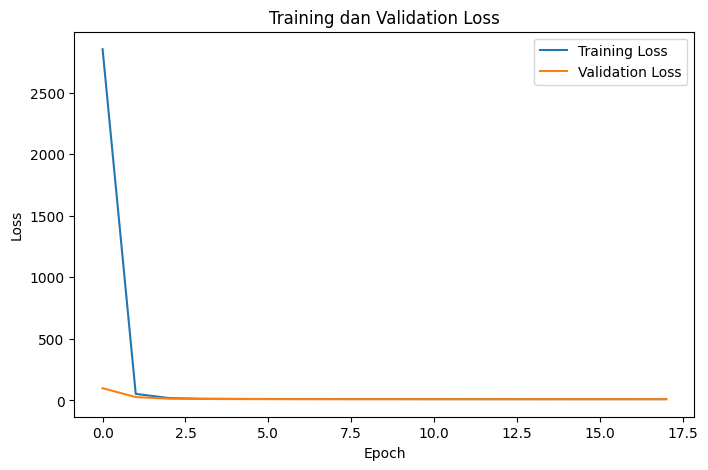

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training dan Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

#Save Model

In [63]:
import joblib
from google.colab import files

#ML
rf_model = models['Random Forest Regressor']
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(scaler, 'scaler_ml.pkl')

files.download('rf_model.pkl')
files.download('scaler_ml.pkl')

#ANN
model.save('calories_model.h5')
joblib.dump(scaler_ann, 'scaler_ann.pkl')

files.download('calories_model.h5')
files.download('scaler_ann.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Kesimpulan & Analisis

### Perbandingan Model Machine Learning Tradisional dan ANN


1.  **Random Forest Regressor** ( best traditional ML model)
2.  **Artificial Neural Network (ANN)**

In [64]:
print('--- Random Forest Regressor Performance (Test Data) ---')

rfr_row = df_eval[
    (df_eval['Model'] == 'Random Forest Regressor') &
    (df_eval['Data'] == 'Test')
]

print(f"R2 Score: {rfr_row['R2 Score'].values[0]}")
print(f"MAE: {rfr_row['MAE'].values[0]}")
print(f"RMSE: {rfr_row['RMSE'].values[0]}")


print('\n--- ANN Model Performance (Test Data) ---')
print(f"ANN R2: {r2_score(y_test, y_pred_ann):.4f}")
print(f"ANN MAE: {mean_absolute_error(y_test, y_pred_ann):.2f}")

rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
print(f"ANN RMSE: {rmse_ann:.2f}")

--- Random Forest Regressor Performance (Test Data) ---
R2 Score: 99.66%
MAE: 2.54 Kkal
RMSE: 3.70

--- ANN Model Performance (Test Data) ---
ANN R2: 0.9972
ANN MAE: 2.35
ANN RMSE: 3.37


Dari hasil di atas, terlihat perbandingan performa model antara Random Forest Regressor dan ANN dan dapat dikatakan kedua model tsb menunjukkan performa yang sangat baik dalam memprediksi kalori yang terbakar selama olaraga, dengan nilai R2 Score di atas 99% dan MAE yang rendah.

**Secara keseluruhan, model ANN dengan arsitektur model yg dibuat menunjukkan performa sedikit lebih unggul dalam memprediksi jumlah kalori yang terbakar dg dataset yg dipilih dan dengan tingkat akurasi yang lebih tinggi dan error yang lebih rendah dibandingkan dengan Random Forest Regressor.**